In [1]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
from pprint import pprint

from joblib import Parallel, delayed
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device = 'cpu'
print(f'torch device: {device}')
# GNN package
from torch_geometric.loader import DataLoader

import networkx as nx

torch device: cpu


In [2]:
from dataset import CustomDataset, transform_data
from models import CustomModel
from losses import CustomCriterion
from eva import compute_eval

/Users/alan/Documents/ELSA/Woven/Scene/WP-16F/py/venv/lib/python3.9/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2.0 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


torch device: cpu


In [3]:
SOLO_NAME =  'poisson3r8_vis'
SCENE = 'SimpleOffice'
# SCENE = 'WP16'
DATA_DIR = f'../output/{SCENE}/{SOLO_NAME}'

In [4]:
ds = CustomDataset(root=DATA_DIR, scene=SCENE, transform=transform_data)
dl = DataLoader(ds, batch_size=1, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
dc = next(iter(dl))

In [5]:
# ds = CustomDataset(root=DATA_DIR, scene=SCENE)
# ds[0]['node_df'].columns

In [6]:
# # e1is = []
# len_e2 = []
# for dc in iter(dl):
#   e1is.append(len(dc['e1i'][0]))
#   len_e2.append(len(dc['e2i'][0]) + len(dc['e2j'][0]))

# len_e2 = np.array(len_e2)
# for k in [1, 3, 5]:
#   p_rand = np.clip(1 - (len_e2 - k) / len_e2, 0, 1)
#   print(f'rand hits@{k}: {p_rand.mean():.4f}, {p_rand.std():.4f}')

In [7]:
node_attr_dim = dc['node_attr'].shape[2]
node_visual_dim = dc['bbox_embs'].shape[2]
edge_attr_dim = dc['edge_attr'].shape[2]
emb_dim = 128

print(f'node attr dim: {node_attr_dim}')
print(f'node visual dim: {node_visual_dim}')
print(f'edge attr dim: {edge_attr_dim}')
print(f'emb dim: {emb_dim}')

node attr dim: 31
node visual dim: 1000
edge attr dim: 3
emb dim: 128


In [8]:
ds = CustomDataset(root=DATA_DIR, scene=SCENE, transform=transform_data)
# random select 1000 samples from ds
ds = torch.utils.data.Subset(ds, np.random.choice(len(ds), 1000, replace=False))
train_ds, eval_ds, test_ds = torch.utils.data.random_split(ds, [0.5, 0.2, 0.3])
# train_ds = torch.utils.data.Subset(train_ds, [0])  # for debugging

# Do not use batch_size>1 for now, it will crash the e1i, e1j, e2i, e2j indices
train_dl = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=0, pin_memory=True)
eval_dl = DataLoader(eval_ds, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)

print('train size:', len(train_ds))
print('eval size:', len(eval_ds))
print('test size:', len(test_ds))

train size: 500
eval size: 200
test size: 300


In [9]:
def train_step(model, data_dict, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    pred_dict = model(data_dict)
    loss = criterion(pred_dict, data_dict)
    loss.backward()
    optimizer.step()
    return loss.item()

In [10]:
def eval_step(model, data_dict, criterion):
    model.eval()
    # with torch.no_grad():
    pred_dict = model(data_dict)
    loss = criterion(pred_dict, data_dict)
    metrics = compute_eval(pred_dict, data_dict)
    return loss.item(), metrics

In [11]:
model = CustomModel(node_attr_dim, node_visual_dim, edge_attr_dim, emb_dim, match_threshold=0.5).to(device)
criterion = CustomCriterion(device)
optimizer = optim.Adam(model.parameters(), lr=5e-4)

e = 0
history = {'train_loss': [], 'eval_loss': [], 'eval_metrics': []}

  0%|          | 0/10 [00:00<?, ?it/s]

----- epoch: 10 -----
train loss: 2.4230
eval  loss: 2.2954
eval metrics:
acc: 0.5196
pre: 0.1050
rec: 0.0240
f1: 0.0385
hits@1: 0.1703
hits@3: 0.4952
hits@5: 0.6919



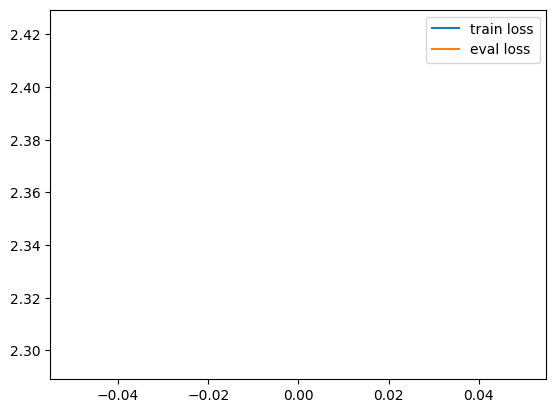

In [12]:
# training loop
for _ in tqdm(range(10)):
    e += 1
    train_loss = 0
    for data_dict in train_dl:
        train_loss += train_step(model, data_dict, optimizer, criterion)
    train_loss /= len(train_dl)

    if e % 10 == 0:
        mean_metrics = {}
        sum_eval_loss = 0

        with torch.no_grad():
            model.eval()
            for data_dict in eval_dl:
                eval_loss, metrics = eval_step(model, data_dict, criterion)
                sum_eval_loss += eval_loss
                for k, v in metrics.items():
                    if k in mean_metrics:
                        mean_metrics[k] = mean_metrics.get(k, 0) + v 
                    else:
                        mean_metrics[k] = v

        for k, v in mean_metrics.items():
            mean_metrics[k] = v / len(eval_dl)
        eval_loss = sum_eval_loss / len(eval_dl)

        history['train_loss'].append(train_loss)
        history['eval_loss'].append(eval_loss)
        history['eval_metrics'].append(mean_metrics)
        print(f'----- epoch: {e} -----')
        print(f'train loss: {train_loss:.4f}')
        print(f'eval  loss: {eval_loss:.4f}')
        print('eval metrics:')
        for k, v in mean_metrics.items():
            print(f'{k}: {v:.4f}')
        print()

plt.plot(history['train_loss'], label='train loss')
plt.plot(history['eval_loss'], label='eval loss')
plt.legend()
plt.show()

In [13]:
mean_metrics = {}
sum_test_loss = 0

with torch.no_grad():
    model.eval()
    for data_dict in tqdm(test_dl):
        test_loss, metrics = eval_step(model, data_dict, criterion)
        sum_test_loss += test_loss

        pred_dict = model(data_dict) 
        # matches = matches_from_scores(pred_dict['scores'], 0.5)
        # cfm = compute_confusion_matrix(matches['matches0'], matches['matches1'], data_dict)
        # metrics['cfm_acc'] = cfm['acc']
        # metrics['cfm_pre'] = cfm['pre']
        # metrics['cfm_rec'] = cfm['rec']
        # metrics['cfm_f1'] = cfm['f1']

        for k, v in metrics.items():
            if k in mean_metrics:
                mean_metrics[k] = mean_metrics[k] + v
            else:
                mean_metrics[k] = v
        


for k, v in mean_metrics.items():
    mean_metrics[k] = v / len(test_dl)

mean_test_loss = sum_test_loss / len(test_dl)
print(f'mean_test loss: {mean_test_loss:.4f}')
print('test metrics:')
for k, v in mean_metrics.items():
    print(f'{k}: {v:.4f}')

  0%|          | 0/300 [00:00<?, ?it/s]

mean_test loss: 2.3342
test metrics:
acc: 0.5450
pre: 0.0989
rec: 0.0204
f1: 0.0331
hits@1: 0.1536
hits@3: 0.4764
hits@5: 0.6754


In [26]:
data_dict = list(iter(test_dl))[10]
pred_dict = model(data_dict)
cam_pose = data_dict['g1_camera_pose']

with torch.no_grad():
    metrics = compute_eval(pred_dict, data_dict)
    for k, v in metrics.items():
        if type(v) == torch.Tensor:
            metrics[k] = v.item()
pprint(metrics)

{'acc': 0.4666666666666667,
 'f1': 0.2,
 'hits@1': 0.2222222222222222,
 'hits@3': 0.5555555555555556,
 'hits@5': 0.7777777777777778,
 'pos0_mae': 49.056549173828124,
 'pos0_mse': 37.56290868605101,
 'pos1_mae': 27.04133820875549,
 'pos1_mse': 18.50219555187157,
 'pre': 1.0,
 'rec': 0.1111111111111111}


/Users/alan/Documents/ELSA/Woven/Scene/WP-16F/py/models.py:285: RuntimeWarning: invalid value encountered in sqrt
  q[0] = np.sqrt(1.0 + R[0, 0] + R[1, 1] + R[2, 2]) / 2.0


In [ ]:
# turn e1i and e1j into numpy array
e1i = data_dict['e1i'].squeeze(0).numpy()
e1j = data_dict['e1j'].squeeze(0).numpy()
e2i = data_dict['e2i'].squeeze(0).numpy() - data_dict['g1_node_count'].item()
e2j = data_dict['e2j'].squeeze(0).numpy() - data_dict['g2_node_count'].item()
e1 = np.concatenate([e1i, e1j])
e2 = np.concatenate([e2i, e2j])
print('g1 node count', data_dict['g1_node_count'].item())
print('g2 node count', data_dict['g2_node_count'].item())
print(f'e1i: {e1i.shape}, e2i: {e2i.shape}, e1j: {e1j.shape}, e2j: {e2j.shape}')
# print(f'e1: {e1}')
# print(f'e2: {e2}')

In [ ]:
gt_match = [[i, j] for i, j in zip(e1i, e2i)]
pred_match = [[i, j.item()] for i, j in enumerate(pred_dict['matches0']) if j != -1]

print(f'gt match:')
pprint(gt_match)
print(f'pred match:')
pprint(pred_match)

In [ ]:
# gt_match = [[i, j] for i, j in zip(e1i, e2i)]
# print(f'gt match:')
# pprint(gt_match)

# g1_node_count = data_dict['g1_node_count'][0].detach().cpu().numpy()
# emb = pred_dict['joint_embs'].squeeze(0).detach().cpu().numpy()
# emb = emb / np.linalg.norm(emb, axis=1)[:, None]
# emb1 = emb[:data_dict['g1_node_count']]
# emb2 = emb[data_dict['g1_node_count']:]
# W = emb1 @ emb2.T
# corr_ids = np.argmax(W, axis=1) + g1_node_count

# G = nx.Graph()
# for i in range(W.shape[0]):
#     for j in range(W.shape[1]):
#         G.add_edge(i, j + g1_node_count, weight=W[i, j])

# match = nx.bipartite.minimum_weight_full_matching(G, corr_ids)
# match = [[i, j] for i, j in match.items() if i < data_dict['g1_node_count'].item()]
# print(f'pred match:')
# pprint(match)

# match_G = nx.Graph()
# for i in match.keys():
#     j = match[i]
#     match_G.add_edge(i, j, weight=G[i][j]['weight'])
# pos = nx.bipartite_layout(match_G, match.keys())
# nx.draw(match_G, pos, node_color='lightblue', with_labels=True, node_size=500)